# UPRM Hackathon 2026 - Object Detection using Convolutional Neural Networks

**Author:** Hamzah Abdulrazzaq, Chelsea Cantone, Erika Hall, Edgar Perez

**Date:** September 25-27, 2026

**Objective:** UPRM Hackathon 2026 will be focused on exploring the capabilities of Convolutional Neural Networks (CNNs) in tackling complex object detection tasks. Specifically, participants will delve into the realm of single-class object detection using the 'Remondis Contamination Dataset' (RCD), which comprises truck-mounted waste camera imagery captured in real-world waste management operations. The dataset includes KITTI-format annotated images featuring plastic_bag instances of varying sizes, occlusion levels, lighting conditions, and background clutter, with bounding-box labels marking each target object. The task at hand is to design and optimize CNN-based detection architectures to accurately localize and classify plastic bags within a given image. The challenge lies in developing a robust model that can effectively handle the complexities of bounding-box regression combined with classification, requiring meticulous attention to data preprocessing, hyper-parameter tuning, and potentially incorporating techniques such as transfer learning, data augmentation, anchor tuning, and ensemble methods. The winning submissions will be evaluated based on their performance, with a key metric being the model's ability to achieve high mean Average Precision at IoU 0.50 (mAP@50) on the validation split, balancing precision and recall across detected instances.

## Table of Contents
1. [Background Information](#1-background-information)
    - [1.1. Convolutional Neural Networks](#11-convolutional-neural-networks)
    - [1.2. Object Detection vs Image Classification (Multi-label)](#12-object-detection-vs-image-classification-multi-label)
    - [1.3 An Example Use Case of Object Detection for Lockheed Martin](#13-an-example-use-case-of-object-detection-for-lockheed-martin)
    - [1.4 Key Terms](#14-key-terms)
    - [1.5 Helpful Resources](#15-helpful-resources)
2. [Setup](#2-setup)
    - [2.1. Download Data](#21-download-data)
    - [2.2 Importing Necessary Libraries](#22-importing-necessary-libraries)
    - [2.3 Custom Image Dataset](#23-custom-image-dataset)
    - [2.4 Image Augmentation](#24-image-augmentation)
3. [Training Loop](#3-training-loop)
    - [3.1 CNN Model Architecture](#31-cnn-model-architecture)
    - [3.2 Model Training](#32-model-training)
4. [Analysis](#4-analysis)
    - [4.1 Visualize Ground Truth vs Predictions](#41-visualize-ground-truth-vs-predictions)
    - [4.2 Performance Analysis (Where is the model underperforming)](#43-performance-analysis-where-is-the-model-underperforming)
5. [Test](#5-test)
    - [5.1 Download Test Data](#51-download-test-data)
    - [5.2 Create Test DataLoader](#51-create-test-dataloader)
    - [5.3 Grade Model on Test Set](#52-grade-model-on-test-set)
6. [Grading/Submission Guidelines](#6-gradingsubmission-guidelines)

## 1. Background Information

### 1.1 Convolutional Neural Networks:

A convolutional neural network (CNN or ConvNet) is a class of deep neural networks, most commonly applied to analyzing visual imagery. They have proven to be very effective in image and video recognition, recommender systems, image classification, medical image analysis, natural language processing, brain-computer interfaces, and financial time series modeling. CNNs are regularized versions of multilayer perceptrons. Multilayer perceptrons usually mean fully connected networks, that is, each neuron in one layer is connected to all neurons in the next layer. The "fully-connectedness" of these networks makes them prone to overfitting data. Typical ways of regularization include adding some form of magnitude measurement of weights to the loss function. CNNs take a different approach towards regularization: they take advantage of the hierarchical pattern in data and assemble more complex patterns using smaller and simpler patterns. Therefore, on the scale of connectedness and complexity, CNNs are on the lower extreme. Convolutional networks were inspired by biological processes in that the connectivity pattern between neurons resembles the organization of the animal visual cortex. Individual cortical neurons respond to stimuli only in a restricted region of the visual field known as the receptive field. The receptive fields of different neurons partially overlap such that they cover the entire visual field.

### 1.2 Object Detection vs Image Classification (Multi-label)

![choose_computer_vision_arch.png](./img/choose_computer_vision_arch.png)

*[Image Source](https://storage.ghost.io/c/2c/8d/2c8d8c0d-1c15-4b6d-825e-02b78d61d40a/content/images/size/w1000/size/w2000/2020/07/choose_computer_vision_arch.png)*

Object detection vs image classification are two related but different challenges in computer vision. Object detection looks at digital images and videos to locate objects of interest and label them.

| Image Classification (multi-label) | Object Detection |
| :--- | :--- |
| *Questions*: What labels are present in this image? | *Questions*: Is there an object here (objectness)? Where are the objects in the image (localization)? What labels are present (classification)? |
| *Output*: Class probabilities | *Output*: Bounding boxes, class probabilities, confidence scores (objectness) |
| *Evaluation metric*: F1-score | *Evaluation metric*: mAP@50 IoU, mean average precision at 50% Intersection over Union |

For explanation of mAP, see the references section below. mAP@50 indicates the mean Average Precision, where the Intersection over Union threshold is set to 0.5. Practically this means that the overlap of the ground truth bounding box to the predicted bounding box sufficiently overlap.

![Intersection over Union](./img/IoU-graphic.png)

[*Source*](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*FrmKLxCtkokDC3Yr1wc70w.png)

### 1.3 An Example Use Case of Object Detection for Lockheed Martin
> GATR (Globally-scalable Automated Target Recognition) is a Lockheed Martin software system for real-time object detection and classification in satellite imagery on a worldwide basis. 
![GATR Object Detection](./img/Screenshot%202026-08-10%20134544.png)

[*Globally-scalable Automated Target Recognition (GATR) 2019*](https://arxiv.org/pdf/2009.04836)

### 1.4 Key Terms:
- **Anchor box** - in some object detection CNN models predefined reference boxes, of fixed size and aspect ratio, are used to localize objects
- **Backbone** - a backbone is a very unspecialized CNN that is inserted into a computer vision model to extract essential visual features from raw images (edges, corners, textures, shapes, etc.) into a feature map. Example backbone are ResNet, CSPNet, or a Vision Transformer.
- **Bounding box (bbox)** - the rectangular frame surrounding an object in an image or video. Our labeled dataset contains ground truth bounding boxes that were annotated by humans. We will compare the bounding boxes generated by our model to the ground truth annotations.
- **Localization** - uses regression to predict four numbers representing bounding box coordinates (center point, width, and height).
- **Objectness** - in computer vision, measure that scores how likely a specific image window contains an actual object rather than background.
- **Non-Maximum Suppression (NMS)** - A post processing technique to remove overlapping bounding boxes of the same objecct. Some computer vision models do not deal with this challenge.


### 1.5 Helpful Resources:

Neural Networks:
- [What are Convolutional Neural Networks](https://www.bing.com/videos/search?q=convolutional+neural+network&docid=603549927117705930&mid=E7ED04059A9474B24BFEE7ED04059A9474B24BFE&view=detail&FORM=VIRE)
- [CNN Explainer - Learn CNN In Your Browser](https://poloclub.github.io/cnn-explainer/)
- [Neural Network Playground](https://playground.tensorflow.org/)
- [Interactive Demo for Image kernels](https://deeplizard.com/resource/pavq7noze2)
- [Introduction to Pooling Layers](https://www.geeksforgeeks.org/deep-learning/cnn-introduction-to-pooling-layer/)

Object Detection
- [Overview of Object Detection](https://machinelearningmastery.com/object-recognition-with-deep-learning/)
- [Anchor-Based vs Anchor-Free Object Detection](https://www.abhik.ai/concepts/computer-vision/anchor-based-vs-anchor-free)
- [YOLO Object Detection Explained](https://www.datacamp.com/blog/yolo-object-detection-explained)
- [mAP (mean Average Precision) for Object Detection](https://jonathan-hui.medium.com/map-mean-average-precision-for-object-detection-45c121a31173)

## 2. Setup

### 2.1. Download Data

Unzip your data into the data/ folder so the folder structure looks like:

```
data/
  training/
    image_2/    # *.jpg
    label_2/    # *.txt (KITTI format)
  val/
    image/      # *.jpg
    label/      # *.txt (KITTI format)
```


### 2.2 Importing Necessary Libraries

In [1]:
!pip install -r requirements.txt

In [2]:
import math
import os
import random
from pathlib import Path
from typing import Callable, Dict, List, Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.ops import boxes as box_ops
import torchvision.transforms.functional as TF
from PIL import Image

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Repository root (assumes the notebook lives in <repo>/event_materials/).
REPO_ROOT = Path.cwd().parent if Path.cwd().name == "event_materials" else Path.cwd()

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Class id 0 is reserved for background in torchvision detection models.
CLASS_NAME_TO_ID = {"plastic_bag": 1}
NUM_CLASSES = 1 + len(CLASS_NAME_TO_ID)  # background + foreground

print(f"Using device: {DEVICE}")
print(f"NUM_CLASSES (background + foreground): {NUM_CLASSES}")
print(f"Repo root: {REPO_ROOT}")

if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))
else:
    print("No CUDA GPU detected.")
    

Using device: cuda
NUM_CLASSES (background + foreground): 2
Repo root: /home/sagemaker-user/Lockheed_2026_Hackathon
NVIDIA A10G


In [3]:
if torch.cuda.is_available():
    # Returns bytes; convert to MB
    allocated = torch.cuda.memory_allocated(0) / 1024**2
    reserved = torch.cuda.memory_reserved(0) / 1024**2
    
    print(f"Allocated by PyTorch Tensors: {allocated:.2f} MB")
    print(f"Cached/Reserved by PyTorch:    {reserved:.2f} MB")
    
    # Or print a highly detailed diagnostic summary
    print(torch.cuda.memory_summary(device=0))

Allocated by PyTorch Tensors: 0.00 MB
Cached/Reserved by PyTorch:    0.00 MB
|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|       from large pool |      0 B   |      0 B   |      0 B   |      0 B   |
|       from small pool |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   | 

In [4]:
import warnings 
warnings.filterwarnings("ignore")

### 2.3 Custom Image Dataset

A PyTorch Custom Image Dataset is a class that inherits from PyTorch's Dataset class which provides a way to create a dataset that is tailored to your requirements and needs. It integrates efficiently with PyTorch's DataLoader, allowing us to load and process images in batches during model training and validation

#### What is it used for?
- Data Loading: Standardized way to load images and labels from disk.
- Data Preprocessing: Consistent application of transformations (resizing, augmentation, etc.) to images.
- Batch Creation: Mini-batch generation for training.
- Memory Efficiency: Load images only when needed rather than storing entire dataset in memory. 

Provided below is a custom image dataset that you may use for this challenge. You may add your own modifications by reading through [PyTorch's documentation](https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html). 

In [5]:
# Directory names differ between the two splits (hard-coded on disk).
_SPLIT_DIRS = {
    "train": ("image", "label"),
    "val":   ("image",   "label"),
    "test": ("image", "label")
}


def _parse_kitti_label(label_path: Path) -> Tuple[List[List[float]], List[int]]:
    """Parse a single KITTI-format .txt file into boxes and labels.

    Returns (boxes_xyxy, labels). Boxes with non-positive width/height are dropped.
    Only foreground classes in CLASS_NAME_TO_ID are kept; others are silently ignored.
    """
    boxes: List[List[float]] = []
    labels: List[int] = []
    if not label_path.exists():
        return boxes, labels
    with open(label_path, "r") as f:
        for raw in f:
            parts = raw.strip().split()
            if len(parts) < 8:
                continue
            cls = parts[0]
            if cls not in CLASS_NAME_TO_ID:
                continue
            xmin, ymin, xmax, ymax = (float(parts[4]), float(parts[5]),
                                      float(parts[6]), float(parts[7]))
            if xmax <= xmin or ymax <= ymin:
                continue
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(CLASS_NAME_TO_ID[cls])
    return boxes, labels


class KittiPlasticBagDataset(Dataset):
    """PyTorch Dataset over KITTI-format plastic-bag data (self-contained version)."""

    def __init__(
        self,
        root,
        split: str = "train",
        transforms: Optional[Callable] = None,
    ) -> None:
        if split not in _SPLIT_DIRS:
            raise ValueError(f"split must be one of {list(_SPLIT_DIRS)}, got {split!r}")
        self.split = split
        self.transforms = transforms

        root = Path(root)
        # Accept either the repo `data/` folder or a specific split root.
        if (root / "training").is_dir() and (root / "val").is_dir():
            split_root = root / ("training" if split == "train" else split)
        else:
            split_root = root
        img_dir_name, lbl_dir_name = _SPLIT_DIRS[split]
        self.image_dir = split_root / img_dir_name
        self.label_dir = split_root / lbl_dir_name
        if not self.image_dir.is_dir():
            raise FileNotFoundError(f"Image dir not found: {self.image_dir}")
        if not self.label_dir.is_dir():
            raise FileNotFoundError(f"Label dir not found: {self.label_dir}")

        stems = sorted(p.stem for p in self.image_dir.glob("*.jpg"))
        self.ids: List[str] = [s for s in stems if (self.label_dir / f"{s}.txt").exists()]
        if not self.ids:
            raise RuntimeError(f"No paired image/label files found under {split_root}")

    def __len__(self) -> int:
        return len(self.ids)

    def __getitem__(self, idx: int):
        stem = self.ids[idx]
        img_path = self.image_dir / f"{stem}.jpg"
        lbl_path = self.label_dir / f"{stem}.txt"

        img = Image.open(img_path).convert("RGB")
        boxes, labels = _parse_kitti_label(lbl_path)

        if boxes:
            boxes_t = torch.as_tensor(boxes, dtype=torch.float32)
            labels_t = torch.as_tensor(labels, dtype=torch.int64)
        else:
            boxes_t = torch.zeros((0, 4), dtype=torch.float32)
            labels_t = torch.zeros((0,), dtype=torch.int64)

        target = {
            "boxes": boxes_t,
            "labels": labels_t,
            "image_id": torch.tensor([idx], dtype=torch.int64),
        }

        if self.transforms is not None:
            img, target = self.transforms(img, target)
        else:
            img = TF.to_tensor(img)

        return img, target


def detection_collate_fn(batch):
    """Detection targets are variable-length; keep them as a tuple of dicts."""
    images, targets = list(zip(*batch))
    return list(images), list(targets)


### 2.4 Image Augmentation

Image augmentation is an absolutely wonderful way to artificially expand your training dataset, which is especially valuable when working with limited data — a common constraint in real-world image tasks. By creating variations of existing images through transformations like rotations, flips, zooms, and crops, you essentially teach your CNN to recognize objects under different viewing conditions without collecting additional data.

More fundamentally, augmentation directly addresses overfitting by preventing the network from memorizing exact pixel patterns. When a CNN sees the same exact images repeatedly, it tends to learn specific pixel configurations rather than generalizable features. By presenting slightly different versions each time, you force the network to learn robust representations that capture the essence of objects rather than superficial details.

Augmentation also introduces invariance properties into your model. For classification tasks, whether an image is slightly rotated, zoomed, or shifted shouldn't change the label. By training with these variations, your CNN develops translation, rotation, and scale invariance—crucial properties for real-world deployment where objects rarely appear in perfectly consistent positions or orientations.

The CustomImageDataset created above is setup to handle image transforms. An example is provided below with horizontal flip and color jitter transforms applied. See documentation [here](https://docs.pytorch.org/vision/stable/transforms.html?highlight=compose)


In [6]:
from torchvision.transforms import ColorJitter


class TrainTransforms:
    """Light on-the-fly augmentation for the training split.

    - Random horizontal flip (with box coord update).
    - Photometric color jitter (brightness/contrast/saturation/hue) applied
      to the PIL image before tensor conversion. Reduces train/val
      overconfidence gap without needing to re-map bounding boxes.
    - PIL -> float tensor in [0, 1], CHW.
    """

    def __init__(self, hflip_prob: float = 0.5) -> None:
        self.hflip_prob = float(hflip_prob)
        self.color_jitter = ColorJitter(
            brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05,
        )

    def __call__(self, img: Image.Image, target: dict) -> Tuple[torch.Tensor, dict]:
        if self.hflip_prob > 0 and random.random() < self.hflip_prob:
            w = img.width
            img = TF.hflip(img)
            if target["boxes"].numel() > 0:
                boxes = target["boxes"].clone()
                x1 = w - boxes[:, 2]
                x2 = w - boxes[:, 0]
                boxes[:, 0] = x1
                boxes[:, 2] = x2
                target["boxes"] = boxes

        # Photometric jitter operates purely on pixel intensities; boxes
        # are unchanged, so no target update is needed here.
        img = self.color_jitter(img)

        img_t = TF.to_tensor(img)
        return img_t, target

### 2.6 Datasets and DataLoader

In [7]:
DATA_ROOT = REPO_ROOT / "data"
print("Data root:", DATA_ROOT)

train_ds = KittiPlasticBagDataset(root=DATA_ROOT, split="train", transforms=TrainTransforms(hflip_prob=0.5))
val_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="val")

print(f"train samples: {len(train_ds)}")
print(f"val   samples: {len(val_ds)}")

# Modify BATCH_SIZE as needed depending on GPU vs CPU
BATCH_SIZE = 8
# NUM_WORKERS = 0 if running on CPU
NUM_WORKERS = 4

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)

Data root: /home/sagemaker-user/Lockheed_2026_Hackathon/data
train samples: 628
val   samples: 199


## 3. Training Loop

### 3.1 CNN Model Architecture

There are two ways to approaching the model architecture phase of the problem. 

1. Building your own CNN architecture. An example is provided below where modifications can be made. 
2. Using pretrained models.

#### Building Your Own CNN Architecture

__Advantages:__

- Complete control over the architecture design. 
- Freedom to experiment with novel layer arrangements, activation functions, and skip connections.
- No constraints from pretrained weights or architectures that may not be optimal for your domain.
- Typically results in a smaller, more compute efficient model since you only include what you need.

__Disadvantages:__

- Requires a bit more expertise and understanding of Neural Network design
- More epochs are needed as learning must start from random initialization
- Needs much more data to achieve good performance (often prohibitively large amounts)
- Higher risk of overfitting, especially with limited data

#### Using Pretrained Models

__Advantages:__

- Leverage powerful feature extractors trained on massive datasets (like ImageNet with 1.2M images)
- Dramatically reduced training time and computational requirements (though more compute resources are needed to get started)
- Excellent performance even with limited domain-specific data
- Built-in robustness against common image variations and noise
- Access to state-of-the-art architectures (ResNet, EfficientNet, Vision Transformers) without designing them

__Disadvantages:__

- Less control over the underlying architecture
- May include unnecessary complexity for simpler tasks
- Domain shift can be problematic if your images differ significantly from pretraining data
- Fixed input requirements (resolution, channels) that may require preprocessing



#### Object Detection CNN Model Building Blocks
Recall that we are only predicting a single class (plastic bags)
- CNN Backbone to extract feature map
- Detection Head to produce objectness score (detecting foreground vs background) and bounding box regression

**CNN Backbone**

A plain convolutional backbone built entirely from `nn.Conv2d`/`nn.BatchNorm2d`/`nn.ReLU`/`nn.max_pool2d`.

Total stride: `2 × 2 × 2 = 8` (three 2x2 max-pool downsampling operations). Stages 4 and 5 keep the feature map at stride 8 rather than downsampling further, giving a denser prediction grid for smaller plastic bags.

In [8]:
class ConvBNReLU(nn.Module):
    """Basic Conv -> BN -> ReLU block (initialized from scratch)."""

    def __init__(self, in_ch: int, out_ch: int, kernel: int = 3, stride: int = 1) -> None:
        super().__init__()
        pad = kernel // 2
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=kernel, stride=stride,
                              padding=pad, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.bn(self.conv(x)))


class FromScratchBackbone(nn.Module):
    """Plain convolutional backbone. Total stride = 8.

    Each stage runs a small stack of stride-1 conv-bn-relu blocks. A 2x2
    MaxPool2d halves the spatial dimensions between stages. We use only
    3 downsampling pools (instead of 4) to keep total stride at 8, which
    produces a denser prediction grid -- better for detecting smaller
    plastic bags. Stages 4 and 5 now run at stride 8 rather than 16.

    No pretrained weights, no torchvision.models components.
    """

    def __init__(self, channels: Tuple[int, int, int, int, int] = (32, 64, 128, 256, 512)) -> None:
        super().__init__()
        c1, c2, c3, c4, c5 = channels

        # 2x2 max pool with stride 2 halves H and W each time it's applied.
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Stage 1: conv -> conv                            (runs at stride 1)
        self.stage1 = nn.Sequential(
            ConvBNReLU(3, c1, kernel=3, stride=1),
            ConvBNReLU(c1, c1, kernel=3, stride=1),
        )
        # Stage 2: conv -> conv                            (runs at stride 4)
        self.stage2 = nn.Sequential(
            ConvBNReLU(c1, c2, kernel=3, stride=1),
            ConvBNReLU(c2, c2, kernel=3, stride=1),
        )
        # Stage 3: conv -> conv -> conv                    (runs at stride 8)
        self.stage3 = nn.Sequential(
            ConvBNReLU(c2, c3, kernel=3, stride=1),
            ConvBNReLU(c3, c3, kernel=3, stride=1),
            ConvBNReLU(c3, c3, kernel=3, stride=1),
        )
        # Stage 4: conv -> conv -> conv                    (runs at stride 8)
        self.stage4 = nn.Sequential(
            ConvBNReLU(c3, c4, kernel=3, stride=1),
            ConvBNReLU(c4, c4, kernel=3, stride=1),
            ConvBNReLU(c4, c4, kernel=3, stride=1),
        )
        # Stage 5: conv -> conv -> conv                    (runs at stride 8)
        self.stage5 = nn.Sequential(
            ConvBNReLU(c4, c5, kernel=3, stride=1),
            ConvBNReLU(c5, c5, kernel=3, stride=1),
            ConvBNReLU(c5, c5, kernel=3, stride=1),
        )

        self.out_channels = c5
        self.stride = 8  # three total pool operations: 2 * 2 * 2

        # Kaiming init (from scratch).
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Stage 1 runs at full input resolution (cheap: only 32 channels).
        x = self.stage1(x)
        x = self.pool(x)                        # -> stride 2

        # Pool before stages 2 and 3 so the wider convs run on downsampled maps.
        x = self.pool(x); x = self.stage2(x)    # -> stride 4
        x = self.pool(x); x = self.stage3(x)    # -> stride 8
        # Stages 4 and 5 keep the feature map at stride 8 for a denser prediction
        # grid. This costs memory but gives more candidate cells per object.
        x = self.stage4(x)                      # -> stride 8
        x = self.stage5(x)                      # -> stride 8
        return x


# Sanity check: shapes.
_bb = FromScratchBackbone()
with torch.no_grad():
    _dummy = torch.randn(1, 3, 384, 640)
    _feat = _bb(_dummy)
print("Backbone output shape:", tuple(_feat.shape))
print("Backbone out_channels:", _bb.out_channels, " stride:", _bb.stride)


Backbone output shape: (1, 512, 48, 80)
Backbone out_channels: 512  stride: 8


**Detection Head**

A simple convolutional detection head that produces, per grid cell, a 5-channel prediction:

- 1 channel for **objectness logit** (foreground vs. background).
- 4 channels for **box regression** `(tx, ty, tw, th)`.

Since we only have a single foreground class, we don't need class logits per cell — objectness *is* the class score. If you wanted multiple classes, you'd add `num_classes` channels.

In [9]:
class DetectionHead(nn.Module):
    """Small convolutional detection head, initialized from scratch."""

    def __init__(self, in_ch: int, hidden_ch: int = 256, prior_prob: float = 0.01) -> None:
        super().__init__()
        self.stem = nn.Sequential(
            ConvBNReLU(in_ch, hidden_ch, kernel=3, stride=1),
            ConvBNReLU(hidden_ch, hidden_ch, kernel=3, stride=1),
        )
        # 5 = 1 (objectness) + 4 (tx, ty, tw, th)
        self.pred = nn.Conv2d(hidden_ch, 5, kernel_size=1)

        # Bias prior for the objectness channel so that early training is stable.
        bias_init = -math.log((1 - prior_prob) / prior_prob)
        nn.init.zeros_(self.pred.weight)
        nn.init.zeros_(self.pred.bias)
        with torch.no_grad():
            self.pred.bias[0] = bias_init  # objectness prior

    def forward(self, feat: torch.Tensor) -> torch.Tensor:
        """Returns tensor of shape [N, 5, H, W]."""
        return self.pred(self.stem(feat))


**Full Detector**

Wraps backbone + head and implements:
- **Input preprocessing**: normalize + pad to `stride`-divisible size.
- **Target assignment**: for every ground-truth box, mark the grid cell containing its center as positive.
- **Box encoding/decoding**: `(tx, ty)` in cell-relative units; `(tw, th)` as `log(w / stride)`, `log(h / stride)`.
- **Losses**: objectness (BCE-with-logits) + smooth-L1 on box deltas.
- **Postprocess**: sigmoid scores + NMS.

Follows the torchvision detection API:
- In `train()` mode: `forward(images, targets) -> dict[str, Tensor]` of scalar losses.
- In `eval()` mode: `forward(images) -> list[dict]` with `boxes`, `scores`, `labels`.

In [23]:
class FromScratchDetector(nn.Module):
    """Single-scale, anchor-free, from-scratch CNN detector."""

    def __init__(
        self,
        image_mean: Tuple[float, float, float] = (0.485, 0.456, 0.406),
        image_std: Tuple[float, float, float] = (0.229, 0.224, 0.225),
        min_size: int = 512,
        max_size: int = 800,
        # min_size: int = 500,
        # max_size: int = 500,
        score_thresh: float = 0.60,  # raised from 0.01: drop the ~0.10 noise band
        nms_thresh: float = 0.3,     # slightly less aggressive suppression, nms_thresh is IoU score
        detections_per_img: int = 100,
        center_sample_radius: float = 0.4,  # FCOS-style shrink factor for center region
    ) -> None:
        super().__init__()
        self.backbone = FromScratchBackbone()
        self.head = DetectionHead(in_ch=self.backbone.out_channels, hidden_ch=256)
        self.stride = self.backbone.stride

        self.register_buffer("image_mean", torch.tensor(image_mean).view(1, 3, 1, 1))
        self.register_buffer("image_std", torch.tensor(image_std).view(1, 3, 1, 1))
        # Torchvision-style resize policy: scale so the shorter side is `min_size`,
        # unless that would make the longer side exceed `max_size`, in which case
        # scale by `max_size / longer_side`. Aspect ratio is preserved.
        self.min_size = int(min_size)
        self.max_size = int(max_size)
        self.score_thresh = float(score_thresh)
        self.nms_thresh = float(nms_thresh)
        self.detections_per_img = int(detections_per_img)
        self.center_sample_radius = float(center_sample_radius)

    # ------------------------------------------------------------------
    def _preprocess(
        self, images: List[torch.Tensor]
    ) -> Tuple[torch.Tensor, List[Tuple[int, int]], List[float]]:
        """Resize, normalize, and pad a list of image tensors.

        Returns
        -------
        batched:        [N, 3, H, W] resized + normalized + padded tensor.
        original_sizes: list of (H, W) of the *input* images (before resize).
        scales:         list of per-image scale factors (resized / original).
                        Used to map training targets into the resized space
                        and to map predictions back to the original space.
        """
        original_sizes = [(int(img.shape[-2]), int(img.shape[-1])) for img in images]
        device = images[0].device
        dtype = images[0].dtype
        mean = self.image_mean.to(device=device, dtype=dtype)
        std = self.image_std.to(device=device, dtype=dtype)

        processed: List[torch.Tensor] = []
        scales: List[float] = []
        for img in images:
            h, w = int(img.shape[-2]), int(img.shape[-1])
            short, long_ = float(min(h, w)), float(max(h, w))
            scale = self.min_size / short
            if scale * long_ > self.max_size:
                scale = self.max_size / long_

            if scale != 1.0:
                new_h = int(round(h * scale))
                new_w = int(round(w * scale))
                img_r = TF.resize(img, [new_h, new_w], antialias=True)
            else:
                img_r = img

            img_n = (img_r.unsqueeze(0) - mean) / std
            processed.append(img_n)
            scales.append(float(scale))

        max_h = max(t.shape[-2] for t in processed)
        max_w = max(t.shape[-1] for t in processed)
        s = self.stride
        pad_h = int(math.ceil(max_h / s) * s)
        pad_w = int(math.ceil(max_w / s) * s)

        batched = torch.zeros((len(processed), 3, pad_h, pad_w), device=device, dtype=dtype)
        for i, t in enumerate(processed):
            batched[i, :, : t.shape[-2], : t.shape[-1]] = t[0]
        return batched, original_sizes, scales

    # ------------------------------------------------------------------
    def _build_targets(
        self,
        targets: List[Dict[str, torch.Tensor]],
        feat_h: int,
        feat_w: int,
        device: torch.device,
    ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """FCOS-style center-sampled assignment.

        For each GT box, every grid cell whose center falls inside a shrunken
        sub-region of that box (radius ``center_sample_radius`` of the half-size,
        with a floor of ``1.5 * stride`` so small boxes still yield >=1 positive)
        AND inside the GT box itself becomes a positive matched to that GT.
        Ties (a cell inside multiple GT center regions) are broken by choosing
        the GT with the smallest area -- smaller objects are harder to detect
        and are prioritized. This turns ~5-20 cells per GT into positives
        instead of 1, sharpening the objectness sigmoid.

        Returns
        -------
        obj_target: [N, feat_h, feat_w]                 1.0 for positive cells, 0.0 otherwise
        reg_target: [N, feat_h, feat_w, 4]              (tx, ty, tw, th) for positive cells
        pos_mask:   [N, feat_h, feat_w]  (bool)         True where the cell is positive
        """
        n = len(targets)
        obj_target = torch.zeros((n, feat_h, feat_w), device=device)
        reg_target = torch.zeros((n, feat_h, feat_w, 4), device=device)
        pos_mask = torch.zeros((n, feat_h, feat_w), device=device, dtype=torch.bool)
        s = self.stride
        r = self.center_sample_radius
        min_half = 1.5 * s  # minimum half-radius of the center region

        # Grid cell centers in pixel space: (gx + 0.5) * s, (gy + 0.5) * s.
        yy, xx = torch.meshgrid(
            torch.arange(feat_h, device=device, dtype=torch.float32),
            torch.arange(feat_w, device=device, dtype=torch.float32),
            indexing="ij",
        )
        cx_cell = (xx + 0.5) * s  # [feat_h, feat_w]
        cy_cell = (yy + 0.5) * s

        for i, tgt in enumerate(targets):
            boxes = tgt["boxes"].to(device)
            if boxes.numel() == 0:
                continue

            # Box centers, sizes, and areas.
            x1, y1, x2, y2 = boxes[:, 0], boxes[:, 1], boxes[:, 2], boxes[:, 3]
            cx_gt = 0.5 * (x1 + x2)
            cy_gt = 0.5 * (y1 + y2)
            bw = (x2 - x1).clamp(min=1.0)
            bh = (y2 - y1).clamp(min=1.0)
            area = bw * bh  # [G]

            # Sort GTs by area descending so that, when we write into the
            # assignment tensors sequentially, smaller-area boxes overwrite
            # larger ones on overlapping cells (smallest-area wins tiebreak).
            order = torch.argsort(area, descending=True)

            for j in order.tolist():
                cxj, cyj = float(cx_gt[j]), float(cy_gt[j])
                bwj, bhj = float(bw[j]), float(bh[j])
                x1j, y1j = float(x1[j]), float(y1[j])
                x2j, y2j = float(x2[j]), float(y2[j])

                # Center region: box shrunk toward its center by factor r,
                # with a minimum half-radius of 1.5 * stride so small boxes
                # still contain at least one cell center.
                half_w = max(r * 0.5 * bwj, min_half)
                half_h = max(r * 0.5 * bhj, min_half)
                cr_x1 = cxj - half_w
                cr_y1 = cyj - half_h
                cr_x2 = cxj + half_w
                cr_y2 = cyj + half_h

                # Cells whose center is inside the center region AND inside
                # the GT box itself.
                in_center = (
                    (cx_cell >= cr_x1) & (cx_cell <= cr_x2)
                    & (cy_cell >= cr_y1) & (cy_cell <= cr_y2)
                )
                in_box = (
                    (cx_cell >= x1j) & (cx_cell <= x2j)
                    & (cy_cell >= y1j) & (cy_cell <= y2j)
                )
                mask_j = in_center & in_box

                if not mask_j.any():
                    # Fallback: assign the single cell containing the box center
                    # so we never miss a GT (mirrors the old behavior).
                    gx = int(min(max(int(cxj / s), 0), feat_w - 1))
                    gy = int(min(max(int(cyj / s), 0), feat_h - 1))
                    mask_j = torch.zeros_like(mask_j)
                    mask_j[gy, gx] = True

                # Regression targets for cells matched to this GT.
                # tx, ty are cell-relative offsets of the GT center;
                # tw, th are log-space sizes relative to the stride.
                gx_idx = xx[mask_j]  # cell x-index (float)
                gy_idx = yy[mask_j]  # cell y-index (float)
                tx = (cxj / s) - gx_idx
                ty = (cyj / s) - gy_idx
                tw = math.log(bwj / s)
                th = math.log(bhj / s)

                obj_target[i][mask_j] = 1.0
                reg_target[i][mask_j, 0] = tx
                reg_target[i][mask_j, 1] = ty
                reg_target[i][mask_j, 2] = tw
                reg_target[i][mask_j, 3] = th
                pos_mask[i][mask_j] = True

        return obj_target, reg_target, pos_mask

    # ------------------------------------------------------------------
    def _compute_losses(
        self,
        pred: torch.Tensor,   # [N, 5, H, W]
        targets: List[Dict[str, torch.Tensor]],
    ) -> Dict[str, torch.Tensor]:
        n, _, fh, fw = pred.shape
        device = pred.device

        obj_logits = pred[:, 0]                        # [N, H, W]
        reg_pred = pred[:, 1:].permute(0, 2, 3, 1)     # [N, H, W, 4]

        obj_target, reg_target, pos_mask = self._build_targets(targets, fh, fw, device)

        # Objectness loss: sigmoid focal loss.
        # alpha=0.25 down-weights the dominant negative class; gamma=2.0 focuses
        # gradient on hard examples. Normalized by the number of positive cells
        # (RetinaNet convention). This is a more principled way to handle the
        # heavy fg/bg imbalance (~2400 cells vs. 1-3 positives) than BCE +
        # pos_weight.
        alpha, gamma = 0.25, 2.0
        p = torch.sigmoid(obj_logits)
        ce = F.binary_cross_entropy_with_logits(obj_logits, obj_target, reduction="none")
        p_t = p * obj_target + (1 - p) * (1 - obj_target)
        focal = ce * (1 - p_t).pow(gamma)
        alpha_t = alpha * obj_target + (1 - alpha) * (1 - obj_target)
        focal = alpha_t * focal
        num_pos = pos_mask.sum().clamp(min=1).float()
        obj_loss = focal.sum() / num_pos

        # Regression loss (smooth L1) only on positive cells.
        # How does the bounding box compare to ground truth?
        num_pos_int = int(pos_mask.sum().item())
        if num_pos_int > 0:
            reg_loss = F.smooth_l1_loss(
                reg_pred[pos_mask], reg_target[pos_mask], reduction="mean"
            )
        else:
            reg_loss = pred.new_zeros(())

        return {"obj_loss": obj_loss, "reg_loss": reg_loss}

    # ------------------------------------------------------------------
    def _postprocess(
        self,
        pred: torch.Tensor,   # [N, 5, H, W]
        original_sizes: List[Tuple[int, int]],
        scales: List[float],
    ) -> List[Dict[str, torch.Tensor]]:
        n, _, fh, fw = pred.shape
        device = pred.device
        s = self.stride

        obj_scores = torch.sigmoid(pred[:, 0])              # [N, H, W]
        reg = pred[:, 1:].permute(0, 2, 3, 1)               # [N, H, W, 4]

        # Grid cell top-left coordinates in pixel space (resized image coords).
        yy, xx = torch.meshgrid(
            torch.arange(fh, device=device, dtype=pred.dtype),
            torch.arange(fw, device=device, dtype=pred.dtype),
            indexing="ij",
        )

        results: List[Dict[str, torch.Tensor]] = []
        for i, (orig_h, orig_w) in enumerate(original_sizes):
            scales_i = scales[i]
            scores_i = obj_scores[i]                        # [H, W]
            reg_i = reg[i]                                  # [H, W, 4]

            # Decode box centers/sizes (in resized-image pixel coords).
            cx = (xx + reg_i[..., 0]) * s
            cy = (yy + reg_i[..., 1]) * s
            
            # bw = torch.exp(reg_i[..., 2].clamp(max=math.log(1000.0 / 16))) * s
            # bh = torch.exp(reg_i[..., 3].clamp(max=math.log(1000.0 / 16))) * s

            min_log_size = math.log(1.0/s)
            max_log_size = math.log(float(self.max_size) / s)

            bw = torch.exp(reg_i[..., 2].clamp(min=min_log_size, max=max_log_size)) * s
            bh = torch.exp(reg_i[..., 3].clamp(min=min_log_size, max=max_log_size)) * s

            x1 = cx - 0.5 * bw
            y1 = cy - 0.5 * bh
            x2 = cx + 0.5 * bw
            y2 = cy + 0.5 * bh

            boxes = torch.stack([x1, y1, x2, y2], dim=-1).reshape(-1, 4)
            scores = scores_i.reshape(-1)

            # Score threshold
            keep = scores > self.score_thresh
            boxes = boxes[keep]
            scores = scores[keep]

            # Map boxes from resized-image coords back to original-image coords.
            if scales_i != 1.0:
                boxes = boxes / scales_i

            # Clip to original image bounds.
            boxes[:, 0::2] = boxes[:, 0::2].clamp(min=0, max=orig_w)
            boxes[:, 1::2] = boxes[:, 1::2].clamp(min=0, max=orig_h)

            keep_size = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
            boxes = boxes[keep_size]
            scores = scores[keep_size]

            # NMS (Non-Maximum Suppression)
            keep_nms = box_ops.nms(boxes, scores, self.nms_thresh)
            keep_nms = keep_nms[: self.detections_per_img]

            results.append({
                "boxes": boxes[keep_nms],
                "scores": scores[keep_nms],
                # Single-class detector: label is always 1 (plastic_bag).
                "labels": torch.ones(keep_nms.numel(), dtype=torch.int64, device=device),
            })
        return results

    # ------------------------------------------------------------------
    def forward(
        self,
        images: List[torch.Tensor],
        targets: Optional[List[Dict[str, torch.Tensor]]] = None,
    ):
        if self.training and targets is None:
            raise ValueError("Training mode requires targets.")

        batched, original_sizes, scales = self._preprocess(images)
        feat = self.backbone(batched)
        pred = self.head(feat)

        if self.training:
            # Boxes in `targets` are in original-image pixel coords; the model
            # sees the resized image, so scale target boxes to match.
            scaled_targets: List[Dict[str, torch.Tensor]] = []
            for tgt, scale in zip(targets, scales):
                new_tgt = dict(tgt)
                if tgt["boxes"].numel() > 0 and scale != 1.0:
                    new_tgt["boxes"] = tgt["boxes"] * scale
                scaled_targets.append(new_tgt)
            return self._compute_losses(pred, scaled_targets)

        return self._postprocess(pred, original_sizes, scales)

### 3.2 Model Training

Fine-tune a pretrained Faster R-CNN. Its COCO-trained visual features are retained, and its final box predictor is replaced for background + plastic_bag.

In [11]:
# Load a Faster R-CNN pretrained on COCO, then replace its final predictor
# with a two-class head: background (0) and plastic_bag (1).
weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
model = fasterrcnn_resnet50_fpn(weights=weights)
in_features = model.roi_heads.box_predictor.cls_score.in_features
model.roi_heads.box_predictor = FastRCNNPredictor(in_features, NUM_CLASSES)
model = model.to(DEVICE)
# Reduce Faster R-CNN's default 800/1333 resize to lower training cost.
model.transform.min_size = (512,)
model.transform.max_size = 800
# Keep a low score floor for evaluation; visualization applies its own cutoff.
model.roi_heads.score_thresh = 0.01
model.roi_heads.detections_per_img = 100

# Initialize parameters
EPOCHS = 30
LR = 5e-3
MOMENTUM = 0.9
WEIGHT_DECAY = 5e-4
GRAD_CLIP = 5.0
WARMUP_EPOCHS = 1

optimizer = torch.optim.SGD(
    [p for p in model.parameters() if p.requires_grad],
    lr=LR, momentum=MOMENTUM, weight_decay=WEIGHT_DECAY,
)

# Step this schedule once per training batch: warm up over the first epoch,
# then decay smoothly over the remaining training steps.
steps_per_epoch = len(train_loader)
warmup_steps = max(1, WARMUP_EPOCHS * steps_per_epoch)
total_steps = EPOCHS * steps_per_epoch
warmup = torch.optim.lr_scheduler.LinearLR(
    optimizer, start_factor=0.01, end_factor=1.0, total_iters=warmup_steps,
)
cosine = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer, T_max=max(1, total_steps - warmup_steps),
)
scheduler = torch.optim.lr_scheduler.SequentialLR(
    optimizer, schedulers=[warmup, cosine], milestones=[warmup_steps],
)

In [12]:
# Calculate mAP@50 helper function
@torch.no_grad()
def evaluate_map50(model, loader, device) -> float:
    model.eval()
    all_scores: List[float] = []
    all_matches: List[int] = []  # 1 = TP, 0 = FP
    total_gt = 0
    
    # Look through each image and make a prediction
    # Compare each prediction to all ground truth boxes and
    # compute an IoU. If that IoU is >0.50 then consider it a match
    for images, targets in loader:
        images_d = [img.to(device) for img in images]
        # Evaluate a broad confidence range; restore the model's regular cutoff afterward.
        threshold_owner = model if hasattr(model, "score_thresh") else model.roi_heads
        original_score_thresh = threshold_owner.score_thresh
        threshold_owner.score_thresh = min(original_score_thresh, 0.01)
        try:
            preds = model(images_d)
        finally:
            threshold_owner.score_thresh = original_score_thresh
        for pred, tgt in zip(preds, targets):
            gt_boxes = tgt["boxes"]
            total_gt += int(gt_boxes.shape[0])

            p_boxes = pred["boxes"].detach().cpu()
            p_scores = pred["scores"].detach().cpu()

            # Sort predictions by score descending.
            order = p_scores.argsort(descending=True)
            p_boxes = p_boxes[order]
            p_scores = p_scores[order]

            matched = torch.zeros(gt_boxes.shape[0], dtype=torch.bool)
            if gt_boxes.numel() == 0:
                for s in p_scores.tolist():
                    all_scores.append(s)
                    all_matches.append(0)
                continue

            if p_boxes.numel() == 0:
                continue
            
            # IoU calculation against all predicted boxes vs GT boxes
            # in current image
            iou = box_ops.box_iou(p_boxes, gt_boxes)  # [P, G]
            for pi in range(p_boxes.shape[0]):
                ious_p = iou[pi].clone()
                ious_p[matched] = -1.0
                best_iou, best_gt = ious_p.max(dim=0)
                if best_iou.item() >= 0.5:
                    matched[best_gt] = True
                    all_matches.append(1)
                else:
                    all_matches.append(0)
                all_scores.append(float(p_scores[pi].item()))

    if total_gt == 0 or not all_scores:
        return 0.0
    
    # Reorder matches from most to least confidence (high to low objectness)
    scores_t = torch.tensor(all_scores)
    matches_t = torch.tensor(all_matches, dtype=torch.float32)
    order = scores_t.argsort(descending=True)
    matches_t = matches_t[order]

    # Calculate average precision
    tp_cum = torch.cumsum(matches_t, dim=0) # cumulative true‑positives
    fp_cum = torch.cumsum(1 - matches_t, dim=0) # cumulative false‑positives
    recall = tp_cum / max(1, total_gt)
    precision = tp_cum / (tp_cum + fp_cum).clamp(min=1e-9)

    # 11-point interpolated AP (VOC-style).
    # The original PASCAL VOC challenge (2007‑2010) used exactly these 11 recall levels. 
    # The area under the interpolated precision‑recall curve is approximated by taking the 
    # average of the 11 sampled precisions, which yields the Average Precision (AP).
    ap = 0.0
    for t in torch.linspace(0, 1, 11):
        mask = recall >= t
        p = precision[mask].max().item() if mask.any() else 0.0
        ap += p / 11.0
    return float(ap)


In [13]:
# Example training loop
def train_one_epoch(model, loader, optimizer, scheduler, device, epoch: int, log_every: int = 20):
    model.train()
    running = {"loss": 0.0}
    n_batches = 0
    for it, (images, targets) in enumerate(loader):
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        loss_dict = model(images, targets)
        # Faster R-CNN returns separate classifier, box, and proposal losses.
        loss = sum(loss_dict.values())

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        if GRAD_CLIP is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        optimizer.step()
        scheduler.step()

        running["loss"] += float(loss.item())
        for name, value in loss_dict.items():
            running[name] = running.get(name, 0.0) + float(value.item())
        n_batches += 1

        if (it + 1) % log_every == 0:
            parts = "  ".join(
                f"{name}={value/n_batches:.4f}"
                for name, value in running.items() if name != "loss"
            )
            print(f"  epoch {epoch} it {it+1}/{len(loader)}  loss={running['loss']/n_batches:.4f}  {parts}")

    return {k: v / max(1, n_batches) for k, v in running.items()}

In [14]:
import time

# Run train_model function
history = []
best_map50 = -1.0
SAVE_DIR = REPO_ROOT / "models" / "notebook_from_scratch_cnn"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
total_start = time.time()
for epoch in range(1, EPOCHS + 1):
    print(f"---- Epoch {epoch}/{EPOCHS} (lr={optimizer.param_groups[0]['lr']:.5g}) ---")
    epoch_start = time.time()
    stats = train_one_epoch(model, train_loader, optimizer, scheduler, DEVICE, epoch)
    epoch_elapsed = time.time() - epoch_start
    history.append({"epoch": epoch, "elapsed_sec": epoch_elapsed, **stats})
    # Get validation map@50
    map50 = evaluate_map50(model, val_loader, DEVICE)
    print(f"epoch {epoch} validation mAP@50 (plastic_bag): {map50:.4f}")
    if map50 > best_map50:
        best_map50 = map50
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "map50": map50,
            "history": history,
        }, SAVE_DIR / "best.pt")
    parts = "  ".join(f"{k}={v:.4f}" for k, v in stats.items() if k != "loss")
    print(f"epoch {epoch} avg loss={stats['loss']:.4f}  {parts}  elapsed={epoch_elapsed:.2f}s")

total_elapsed = time.time() - total_start
best_checkpoint = torch.load(SAVE_DIR / "best.pt", map_location=DEVICE)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()
print(f"\nBest validation mAP@50: {best_checkpoint['map50']:.4f} at epoch {best_checkpoint['epoch']}")
print(f"Total training time: {total_elapsed:.2f}s ({total_elapsed/60:.2f} min)")

---- Epoch 1/30 (lr=5e-05) ---
  epoch 1 it 20/79  loss=0.7127  loss_classifier=0.3531  loss_box_reg=0.3048  loss_objectness=0.0495  loss_rpn_box_reg=0.0054
  epoch 1 it 40/79  loss=0.6035  loss_classifier=0.2572  loss_box_reg=0.3036  loss_objectness=0.0380  loss_rpn_box_reg=0.0047
  epoch 1 it 60/79  loss=0.5059  loss_classifier=0.2080  loss_box_reg=0.2637  loss_objectness=0.0294  loss_rpn_box_reg=0.0047
epoch 1 validation mAP@50 (plastic_bag): 0.7421
epoch 1 avg loss=0.4626  loss_classifier=0.1897  loss_box_reg=0.2418  loss_objectness=0.0264  loss_rpn_box_reg=0.0046  elapsed=32.52s
---- Epoch 2/30 (lr=0.005) ---
  epoch 2 it 20/79  loss=0.2717  loss_classifier=0.1082  loss_box_reg=0.1510  loss_objectness=0.0093  loss_rpn_box_reg=0.0032
  epoch 2 it 40/79  loss=0.2778  loss_classifier=0.1103  loss_box_reg=0.1550  loss_objectness=0.0091  loss_rpn_box_reg=0.0034
  epoch 2 it 60/79  loss=0.2658  loss_classifier=0.1050  loss_box_reg=0.1490  loss_objectness=0.0086  loss_rpn_box_reg=0.0033


In [15]:
### Save Best Model Checkpoint
# Cell 36 already saves the best validation model and restores its weights.
torch.save({
    "model_state_dict": model.state_dict(),
    "epoch": best_checkpoint["epoch"],
    "map50": best_checkpoint["map50"],
    "history": history,
}, SAVE_DIR / "best.pt")
print("Saved best checkpoint to:", SAVE_DIR / "best.pt")

Saved best checkpoint to: /home/sagemaker-user/Lockheed_2026_Hackathon/models/notebook_from_scratch_cnn/best.pt


## 4. Analysis

### 4.1 Visualize Training Loss vs Epoch


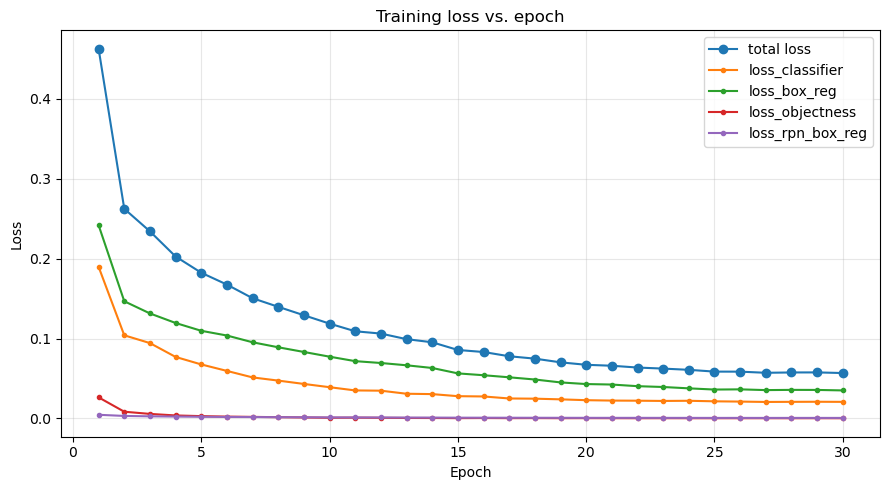

In [16]:
# Plot training loss vs epochs
epochs_x = [h["epoch"] for h in history]
total_loss = [h["loss"] for h in history]
loss_components = [
    key for key in history[0]
    if key not in {"epoch", "elapsed_sec", "loss"}
]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(epochs_x, total_loss, marker="o", label="total loss")
for key in loss_components:
    ax.plot(epochs_x, [h[key] for h in history], marker=".", label=key)
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training loss vs. epoch")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# mAP@50 for training and validation vs Epoch

### 4.2 Performance Analysis (Where is the model underperforming)

In [17]:
# --- Diagnostic: inspect post-NMS prediction scores on the validation set ---
@torch.no_grad()
def diagnose_model(model, loader, device, num_batches: int = 5):
    model.eval()
    max_scores, all_scores = [], []
    n_above = {0.001: 0, 0.01: 0, 0.05: 0, 0.1: 0, 0.3: 0, 0.5: 0}
    num_images = 0

    for bi, (images, targets) in enumerate(loader):
        if bi >= num_batches:
            break
        images_d = [img.to(device) for img in images]
        preds = model(images_d)
        num_images += len(preds)
        for pred in preds:
            scores = pred["scores"].detach().cpu()
            if scores.numel():
                max_scores.append(float(scores.max().item()))
                all_scores.extend(scores.tolist())

    print(f"Over {num_images} validation images:")
    print(f"  highest returned score: {max(max_scores) if max_scores else 0.0:.4f}")
    print(f"  mean returned score:    {sum(all_scores)/len(all_scores) if all_scores else 0.0:.4f}")
    print("  detections above each threshold:")
    for thr, n in n_above.items():
        count = sum(score > thr for score in all_scores)
        print(f"    > {thr:<6}: {count:>7d}")

diagnose_model(model, val_loader, DEVICE, num_batches=5)


Over 40 validation images:
  highest returned score: 0.9987
  mean returned score:    0.4441
  detections above each threshold:
    > 0.001 :     182
    > 0.01  :     182
    > 0.05  :     121
    > 0.1   :     107
    > 0.3   :      89
    > 0.5   :      78


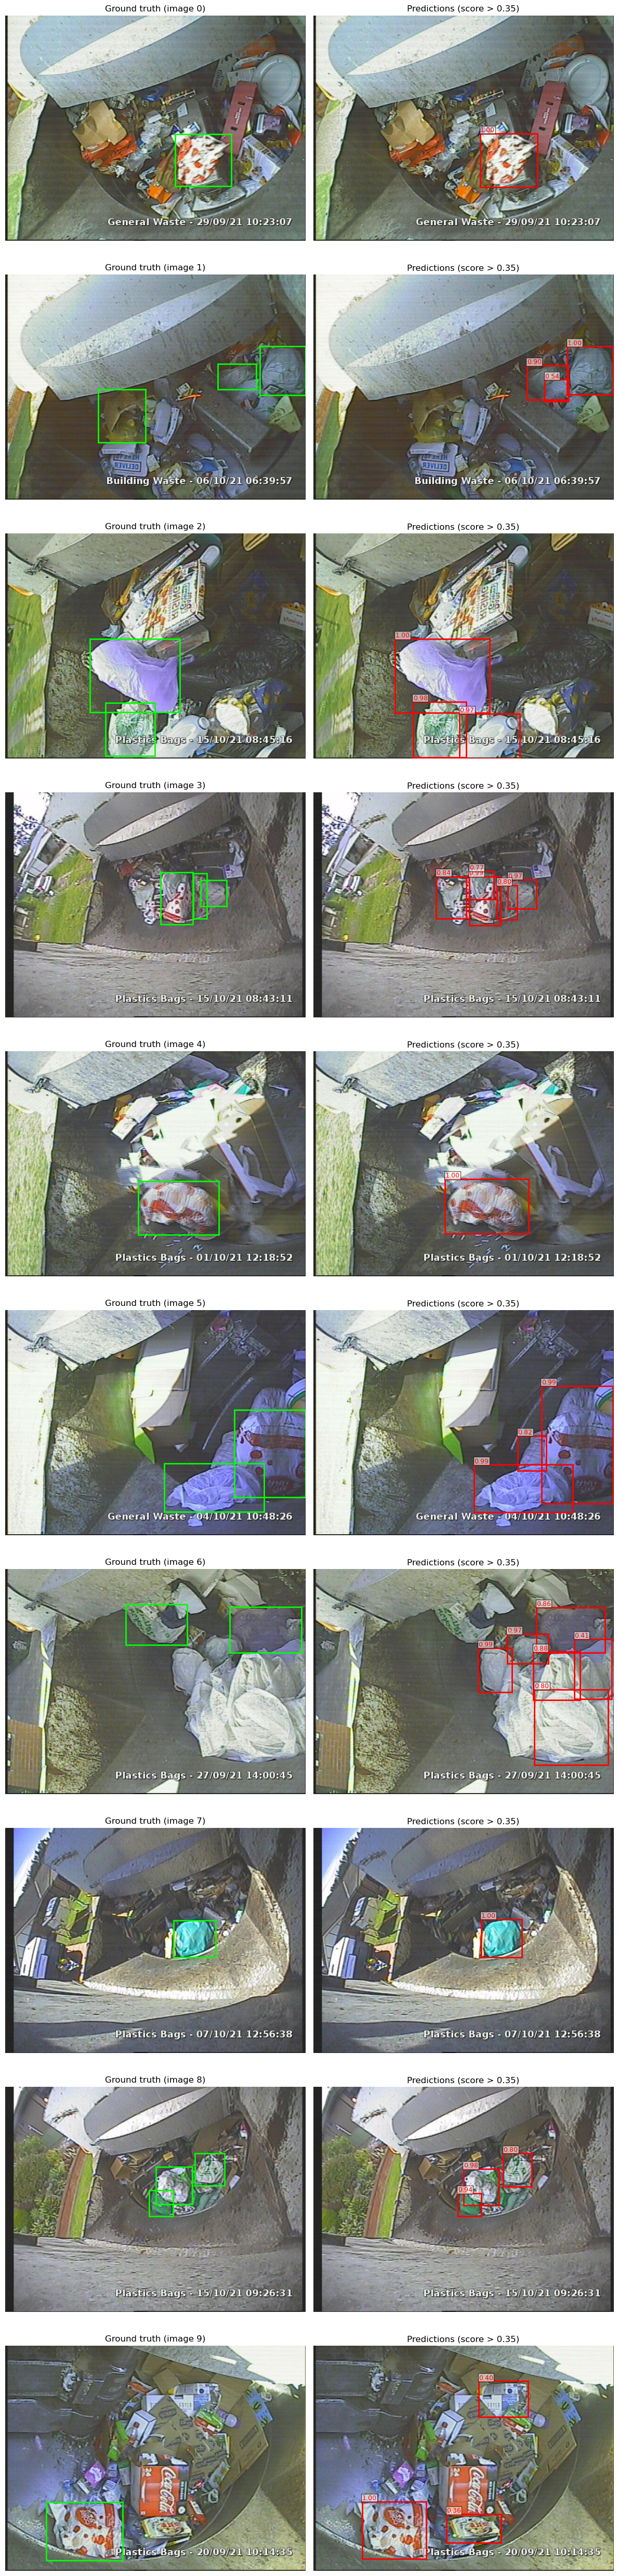

In [21]:
@torch.no_grad()
def visualize_predictions(model, dataset, device, num_images: int = 4, score_thresh: float = 0.3):
    model.eval()
    idxs = list(range(min(num_images, len(dataset))))
    fig, axes = plt.subplots(len(idxs), 2, figsize=(12, 5 * len(idxs)))
    if len(idxs) == 1:
        axes = axes[None, :]

    for row, idx in enumerate(idxs):
        img, target = dataset[idx]
        img_np = img.permute(1, 2, 0).cpu().numpy()

        # Ground truth
        ax_gt = axes[row, 0]
        ax_gt.imshow(img_np)
        ax_gt.set_title(f"Ground truth (image {idx})")
        ax_gt.axis("off")
        for box in target["boxes"]:
            x1, y1, x2, y2 = box.tolist()
            
            ax_gt.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="lime", linewidth=2,
            ))

        # Predictions
        preds = model([img.to(device)])[0]
        ax_pr = axes[row, 1]
        ax_pr.imshow(img_np)
        ax_pr.set_title(f"Predictions (score > {score_thresh})")
        ax_pr.axis("off")
        for box, score in zip(preds["boxes"].cpu(), preds["scores"].cpu()):
            if float(score) < score_thresh:
                continue
            x1, y1, x2, y2 = box.tolist()
            ax_pr.add_patch(patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                fill=False, edgecolor="red", linewidth=2,
            ))
            ax_pr.text(x1, max(0, y1 - 4), f"{float(score):.2f}",
                       color="red", fontsize=9,
                       bbox=dict(facecolor="white", alpha=0.6, pad=1))

    plt.tight_layout()
    plt.show()

# num_images: changes the images when finished running.
visualize_predictions(model, val_ds, DEVICE, num_images=10, score_thresh=0.60)

## 5. Test

Speak to a Hackathon Organizer when your team is ready to submit a final model. You will receive two keys to be entered below to download the test dataset and score your model.

### 5.1 Download Test Data

In [19]:
# Insert keys from Hackathon Organizer
AWS_ACCESS_KEY_ID=""
AWS_SECRET_ACCESS_KEY=""

BUCKET = "uprm-hackathon-data"
PREFIX = "2026/test/"            # trailing slash is optional but recommended
DESTINATION = f"{REPO_ROOT}/data/test/"        # local root folder where files will be saved
REGION = "us-east-1"

In [20]:
import os
import boto3
from pathlib import Path

# Download
s3 = boto3.resource('s3',
                    aws_access_key_id=AWS_ACCESS_KEY_ID,
                    aws_secret_access_key=AWS_SECRET_ACCESS_KEY,
                    region_name=REGION)

bucket = s3.Bucket(BUCKET)

for obj in bucket.objects.filter(Prefix=PREFIX):
    if obj.key.endswith('/'):  # skip “folder” placeholders
        continue
    rel_path = os.path.relpath(obj.key, PREFIX)
    local_path = Path(DESTINATION) / rel_path
    local_path.parent.mkdir(parents=True, exist_ok=True)
    print(f'Downloading {obj.key} → {local_path}')
    bucket.download_file(obj.key, str(local_path))

ClientError: An error occurred (AuthorizationHeaderMalformed) when calling the ListObjects operation: The authorization header is malformed; a non-empty Access Key (AKID) must be provided in the credential.

### 5.2 Create Test DataLoader

In [ ]:
# Create DataLoader for Test Set
test_ds   = KittiPlasticBagDataset(root=DATA_ROOT, split="test")
print(f"test samples: {len(test_ds)}")
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=detection_collate_fn,
    drop_last=False
)

### 5.3 Grade Model on Test Set

In [ ]:
map50 = evaluate_map50(model, test_loader, DEVICE)
print(f"Test mAP@50 (plastic_bag): {map50:.4f}")

# 6. Grading/Submission Guidelines

## Submissions
Please email your submissions to hamzah.abdulrazzaq@lmco.com. All these items must be complete in order for your submission to be considered for evaluation. 
> 1. Email title set to *yourteamname_submission* 
> 2. The python notebook with all your code (.ipynb) 
> 3. Your model checkpoint (.pt) file
> 4. mAP@50 test score copied in with all the digits

**NOTE**: If your email submission is blocked, please try resending the email with a .allow extension added to the file or email title.

## Evaluation Process
> - The submission deadline is on Sunday (9/27) 12PM.
> - Presentations will take place on Sunday (9/27) 2PM for the top 3 teams highest performing solutions. Teams will provide a walkthrough of their code. A winner shall be announced thereafter.